## EDA (探索性資料分析)

### 1. 導入資料與路徑測試

In [14]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 設定繪圖風格
plt.style.use('ggplot')

# 1. 載入資料
# 路徑預設在 notebooks/ 的上一層 data/ 資料夾中
try:
    df = pd.read_csv('../01_data/Fake_Job_Postings.csv')
    print(f"✅ 資料導入成功！目前的數據維度：{df.shape}")
except FileNotFoundError:
    print("❌ 找不到檔案，請確認檔案路徑是否為 ../data/Fake_Job_Postings.csv")

# 2. 預覽前五筆
df.head()

✅ 資料導入成功！目前的數據維度：(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### 2. 資料結構與缺失值檢查 (Data Integrity)

In [15]:
# 1. 查看資料表的整體資訊 (包含欄位名稱、資料型態、非空值數量)
print("--- 資料表基本資訊 ---")
df.info()
# "Non-Null Count"：看看哪些欄位的數量明顯少於總筆數 
# "Dtype"：確認哪些是 "object" (文字)，哪些是 "int64" (數字)

# 2. 計算各欄位缺失值的比例 (0.0 ~ 1.0)
# 乘以 100 轉為百分比
missing_perc = df.isnull().mean() * 100

# 3. 過濾掉沒有缺失的欄位，並由大到小排序
print("=== 各欄位缺失值百分比統計 (%) ===")
print(missing_perc[missing_perc > 0].sort_values(ascending=False))

--- 資料表基本資訊 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  

### 3. 標籤不平衡分析 (Class Imbalance)

--- 詐騙與正常職缺的數量 ---
fraudulent
0    17014
1      866
Name: count, dtype: int64

--- 佔比百分比 (%) ---
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


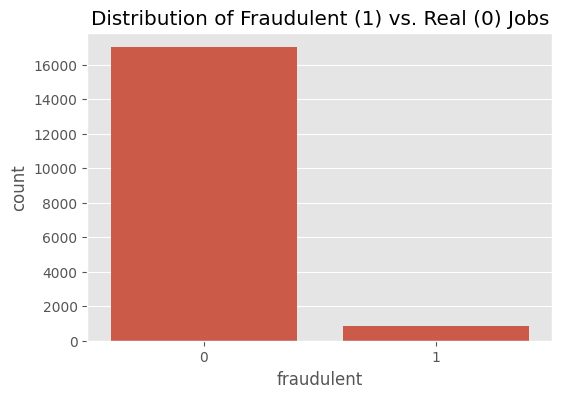

In [16]:
# 1. 統計詐騙 (1) 與正常 (0) 的筆數
print("--- 詐騙與正常職缺的數量 ---")
counts = df['fraudulent'].value_counts()
print(counts)

# 2. 計算佔比百分比
print("\n--- 佔比百分比 (%) ---")
perc = df['fraudulent'].value_counts(normalize=True) * 100
print(perc)

# 3. 視覺化：標籤分佈長條圖
plt.figure(figsize=(6, 4))
sns.countplot(x='fraudulent', data=df)
plt.title('Distribution of Fraudulent (1) vs. Real (0) Jobs')
plt.show()

### 4. 關鍵特徵關聯性：公司標誌 (Logo)

=== 公司 Logo 與詐騙機率對照表 (%) ===
fraudulent                0          1
has_company_logo                      
0                 84.071038  15.928962
1                 98.009845   1.990155


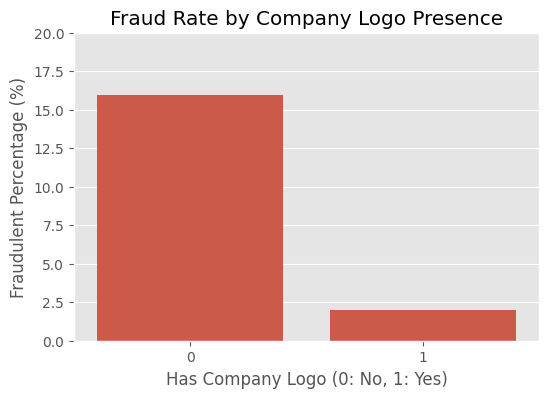

In [17]:
# 1. 建立「有無 Logo」與「是否詐騙」的交叉對照表 (Crosstab)
# normalize='index' 會計算：在「有 Logo」或「沒 Logo」的群體中，詐騙所佔的百分比
logo_fraud_perc = pd.crosstab(df['has_company_logo'], df['fraudulent'], normalize='index') * 100

print("=== 公司 Logo 與詐騙機率對照表 (%) ===")
print(logo_fraud_perc)

# 2. 視覺化：呈現不同組別的詐騙比例
plt.figure(figsize=(6, 4))
# 我們取出 logo_fraud_perc 中 fraudulent 為 1 (詐騙) 的數值來繪圖
sns.barplot(x=logo_fraud_perc.index, y=logo_fraud_perc[1])

plt.title('Fraud Rate by Company Logo Presence')
plt.xlabel('Has Company Logo (0: No, 1: Yes)')
plt.ylabel('Fraudulent Percentage (%)')
plt.ylim(0, 20) # 固定 Y 軸範圍在 0-20%，讓差異更直觀
plt.show()

## 資料處理與特徵工程 (Data Preprocessing & Feature Engineering) 

### 1. 文本整合與欄位合併 (Data Consolidation)

In [18]:
# 1. 填補所有文字欄位的缺失值 (NaN) 為空字串
# 這是為了確保在做字串相加時，不會因為遇到 NaN 而導致整行變成空值
df.fillna('', inplace=True)

# 2. 合併職稱 (title)、工作描述 (description) 與職位要求 (requirements)
# 我們創造一個名為 'text' 的新欄位，作為後續 NLP 處理的核心
df['text'] = df['title'] + " " + df['description'] + " " + df['requirements']

# 3. 預覽合併後的 text 欄位內容
print("--- 合併後的文字欄位預覽 (前五筆) ---")
print(df[['text']].head())

--- 合併後的文字欄位預覽 (前五筆) ---
                                                text
0  Marketing Intern Food52, a fast-growing, James...
1  Customer Service - Cloud Video Production Orga...
2  Commissioning Machinery Assistant (CMA) Our cl...
3  Account Executive - Washington DC THE COMPANY:...
4  Bill Review Manager JOB TITLE: Itemization Rev...


### 2. 正規表示法文字清洗 (Regex Cleaning)

In [19]:
def clean_text(text):
    # 1. 統一轉為小寫：避免 "Money" 與 "money" 被視為不同詞彙
    text = text.lower()
    
    # 2. 移除非英文字母的字元：利用 Regex [^a-zA-Z\s] 剔除數字、標點與特殊符號
    # 這能有效過濾掉 HTML 標籤殘留與無意義的符號
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 3. 壓縮多餘空格：將多個空格合併為單一空格，並修剪首尾
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# 執行清洗：將函數應用到剛剛合併好的 text 欄位
df['text'] = df['text'].apply(clean_text)

# 再次預覽清洗後的結果
print("--- 清洗後的純淨文字預覽 (前五筆) ---")
print(df['text'].head())

--- 清洗後的純淨文字預覽 (前五筆) ---
0    marketing intern food a fast growing james bea...
1    customer service cloud video production organi...
2    commissioning machinery assistant cma our clie...
3    account executive washington dc the company es...
4    bill review manager job title itemization revi...
Name: text, dtype: object


### 3. 特徵與標籤選取 (Feature & Label Selection)

In [20]:
# 1. 定義特徵矩陣 X 與 標籤向量 y
# X 包含我們觀察到的三大關鍵資訊：文字描述、Logo、篩選問題
X = df[['text', 'has_company_logo', 'has_questions']]
y = df['fraudulent']

# 2. 為了之後 Pipeline 處理方便，我們先記錄下哪些欄位是文字，哪些是數值
text_features = 'text'
numeric_features = ['has_company_logo', 'has_questions']

# 3. 檢查資料狀態
print("--- 特徵與標籤選取完成 ---")
print(f"樣本總數: {len(X)}")
print(f"文字特徵欄位: {text_features}")
print(f"數值/類別特徵欄位: {numeric_features}")

# 預覽特徵矩陣
X.head()

--- 特徵與標籤選取完成 ---
樣本總數: 17880
文字特徵欄位: text
數值/類別特徵欄位: ['has_company_logo', 'has_questions']


,text,has_company_logo,has_questions
0,marketing intern food a fast growing james bea...,1,0
1,customer service cloud video production organi...,1,0
2,commissioning machinery assistant cma our clie...,1,0
3,account executive washington dc the company es...,1,0
4,bill review manager job title itemization revi...,1,1


### 4. 清洗後資料存檔

In [21]:
import joblib
import os

# 確保資料夾存在
if not os.path.exists('../01_data'):
    os.makedirs('../01_data')

# 儲存「整份」清洗後的 DataFrame
# 此時還沒切分，所以檔案裡包含所有的資料
joblib.dump(df, '../01_data/cleaned_job_data.joblib')

print("✅ 全量清洗資料已存檔，請前往 02 檔案進行建模實驗！")

✅ 全量清洗資料已存檔，請前往 02 檔案進行建模實驗！


---
---